In [1]:
%load_ext autoreload
%autoreload 2

import torch
from tqdm import tqdm
import numpy as np
np.set_printoptions(precision=4, linewidth=10000, suppress=True)

from omegaconf import OmegaConf
from hydra import compose, initialize
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import sys
sys.path.append('..') # add parent directory
# sys.path.append('../scaling-laws-ecnn/networks') # add parent directory
from networks.network_instantiation import run
from scaling.util import plot_model_data, binary_search_over_model_scaling

In [24]:
def run_test(overrides, verbose, image_size):
    # this is just a test function since gpu is not available right now
    depth = int(overrides[0].split("=")[1])
    width = float(overrides[1].split("=")[1])
    param_count = depth * width * image_size
    model_building_time = 10 * width + 0.5 * depth + 0.01 * image_size**2
    train_time = 0.1 * width + 0.01 * depth + 0.001 * image_size**2

    return param_count, model_building_time, train_time

In [18]:
# test memory footprint of {vs_param}
global_overrides = [
    "model=eq_wrn", 
    "dataset=imagenette",
    "model.restrict=[halved,invariant]",
    "model.kernel_layout=[3,3]", 
    "model.padding=1",
    "wandb.tags=[eff_exp_1]",
    "wandb.mode=disabled",
    "training.epochs=1",
    "model.rotation=8",
    "model.fix_params_mode=heuristic"
]

stats = {}
for mode in [[202,1], [58,1.9]]:
    mode_stats = []
    for image_size in range(32, 106, 10):
        overrides=[f"model.depth={mode[0]}",
                    f"model.widen_factor={mode[1]}"]
        overrides.extend(global_overrides)
        param_count, model_building_time, train_time = run(overrides=overrides, 
                                                            verbose=0, image_size=image_size)
        mode_stats.append([image_size, param_count, model_building_time, train_time])
        
    stats[f"Eq_wrn_{mode[0]}_{mode[1]}"] = np.array(mode_stats)

/home/frischs/scaling-laws-ecnn/scaling/../networks/eq_wrn.py:91: UserWarning: Discretization artifacts are expected for rotation > 4 and                     kernel_layout = [3, 3].
  warnings.warn(f"Discretization artifacts are expected for rotation > 4 and \


Eq_WRN_202_1
Equivariant_WRN params: 2821189
Used: 0.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
Used: 4.0/47.5 GB
U

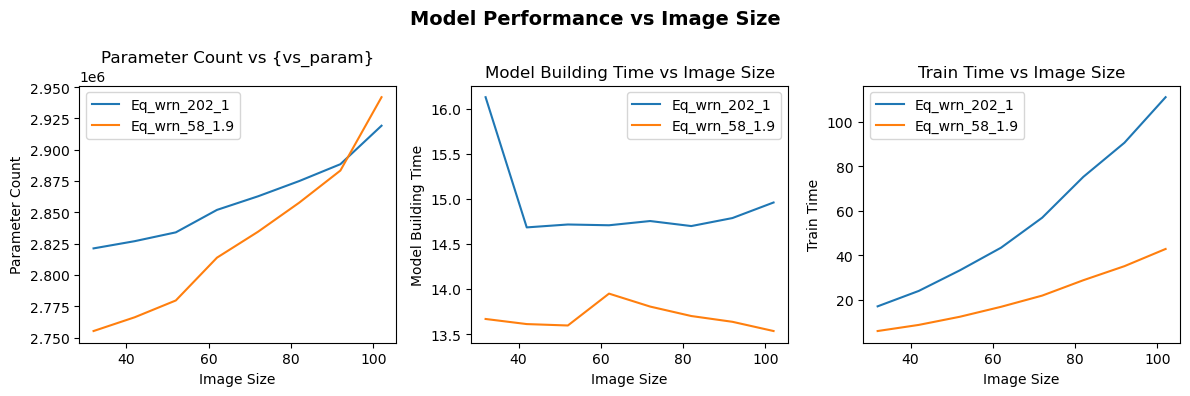

In [19]:
plot_model_data(stats, vs_param="Image Size")

In [2]:
# test memory footprint of rotation
global_overrides = [
    "model=eq_wrn", 
    "dataset=imagenette",
    "model.restrict=[halved,invariant]",
    "model.kernel_layout=[3,3]", 
    "model.padding=1",
    "wandb.tags=[eff_exp_1]",
    "wandb.mode=disabled",
    "training.epochs=1",
    "model.rotation=8",
    "model.fix_params_mode=heuristic"
]
image_size = 64

stats = {}
for mode in [[202,1], [58,1.9]]:
    mode_stats = []
    for rotation in range(2, 16, 2):
        overrides=[f"model.depth={mode[0]}",
                    f"model.widen_factor={mode[1]}",
                    f"model.rotation={rotation}"]
        overrides.extend(global_overrides)
        param_count, model_building_time, train_time = run(overrides=overrides, 
                                                            verbose=0, image_size=image_size)
        mode_stats.append([rotation, param_count, model_building_time, train_time])
        
    stats[f"Eq_wrn_{mode[0]}_{mode[1]}"] = np.array(mode_stats)

/home/frischs/scaling-laws-ecnn/scaling/../networks/eq_wrn.py:91: UserWarning: Discretization artifacts are expected for rotation > 4 and                     kernel_layout = [3, 3].
  warnings.warn(f"Discretization artifacts are expected for rotation > 4 and \


Eq_WRN_202_1
Equivariant_WRN params: 2851909
Eq_WRN_202_1
Equivariant_WRN params: 2851909
Eq_WRN_202_1
Equivariant_WRN params: 2851909
Eq_WRN_202_1
Equivariant_WRN params: 2851909
Eq_WRN_202_1
Equivariant_WRN params: 2851909
Eq_WRN_202_1
Equivariant_WRN params: 2851909
Eq_WRN_202_1
Equivariant_WRN params: 2851909
Eq_WRN_58_1


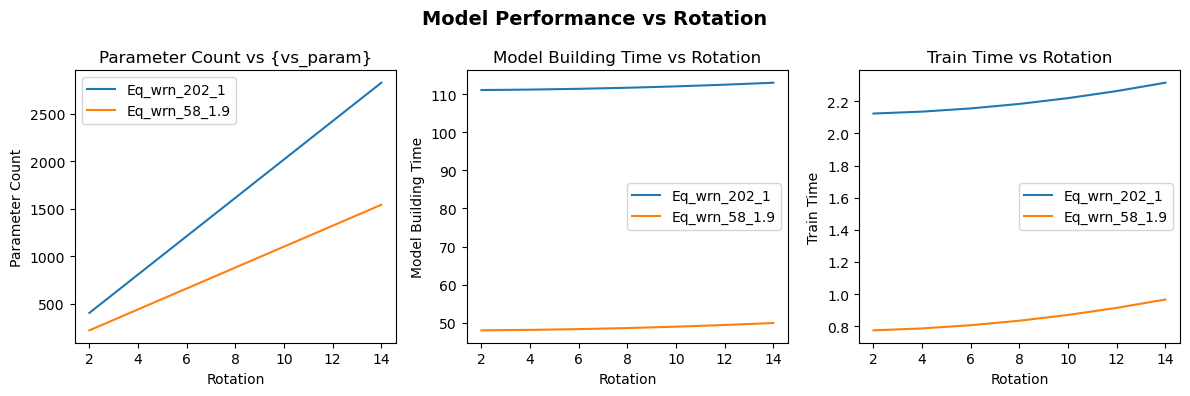

In [ ]:
plot_model_data(stats, vs_param="Rotation")

# Scaling depth, width, image size

In [ ]:
# find best suiting depth, width, resolution (search_param) for increasing 
# the model size, training time (scale_param) by 2 or 4 (scaling_factor).
scaling_factor = 2

global_overrides = {
    "model": "eq_wrn",
    "dataset": "imagenette",
    "model.restrict": ["halved", "invariant"],
    "model.kernel_layout": [3, 3],
    "model.padding": 1,
    "wandb.tags": ["eff_exp_1"],
    "wandb.mode": "disabled",
    "training.epochs": 1,
    "model.rotation": 8,
    "model.fix_params_mode": "heuristic",
}

def depth_constraint(depth):
    n = (depth - 4) // 6
    return 6 * n + 4

search_param = {"model.depth": 58}
scale_param = {"train_time": 1}
initial_range = (search_param["model.depth"], search_param["model.depth"] * 2)
overrides = {"model.widen_factor": 1, "dataset.resolution": 108}

best_depth = binary_search_over_model_scaling(search_param, scale_param, scaling_factor, 
                                              initial_range, depth_constraint,
                                              overrides, global_overrides)



ConfigCompositionException: Could not override 'dataset.resolution'.
To append to your config use +dataset.resolution=108